In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:
df = pd.read_csv("CarPrice_Assignment.csv")
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [22]:
print(df.shape)         
print(df.info())         
print(df.isnull().sum())  
print(df.describe()) 

(205, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    

In [23]:
df['CarBrand'] = df['CarName'].str.split().str[0].str.lower()

brand_map = {
    'maxda'      : 'mazda',
    'vw'         : 'volkswagen',
    'vokswagen'  : 'volkswagen',
    'toyouta'    : 'toyota',
    'porcshce'   : 'porsche',
    'alfa-romero': 'alfa-romeo'
}
df['CarBrand'] = df['CarBrand'].replace(brand_map)

df.drop(columns=['car_ID', 'CarName'], inplace=True)

df.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarBrand
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romeo
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romeo
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romeo
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [24]:
le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

Categorical columns: ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'CarBrand']


,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarBrand
0,3,1,0,1,0,2,0,88.6,168.8,64.1,...,5,3.47,2.68,9.0,111,5000,21,27,13495.0,0
1,3,1,0,1,0,2,0,88.6,168.8,64.1,...,5,3.47,2.68,9.0,111,5000,21,27,16500.0,0
2,1,1,0,1,2,2,0,94.5,171.2,65.5,...,5,2.68,3.47,9.0,154,5000,19,26,16500.0,0
3,2,1,0,0,3,1,0,99.8,176.6,66.2,...,5,3.19,3.40,10.0,102,5500,24,30,13950.0,1
4,2,1,0,0,3,0,0,99.4,176.6,66.4,...,5,3.19,3.40,8.0,115,5500,18,22,17450.0,1


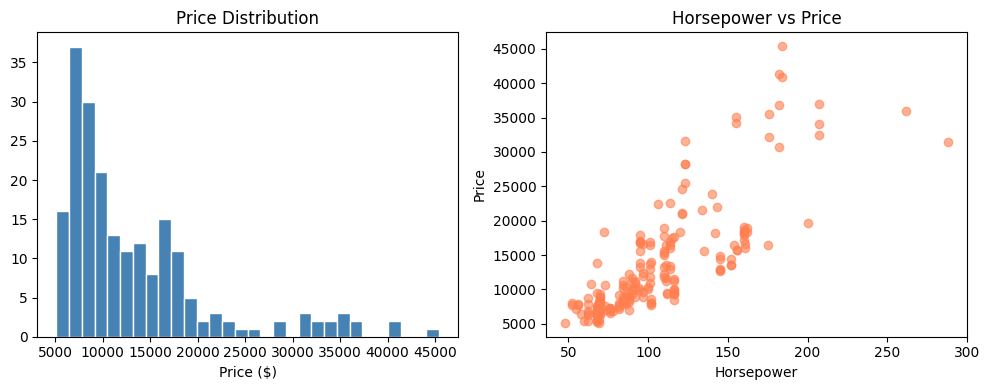

In [25]:
plt.figure(figsize=(10, 4))

# Price Distribution
plt.subplot(1, 2, 1)
plt.hist(df['price'], bins=30, color='steelblue', edgecolor='white')
plt.title('Price Distribution')
plt.xlabel('Price ($)')

# Horsepower vs Price
plt.subplot(1, 2, 2)
plt.scatter(df['horsepower'], df['price'], alpha=0.6, color='coral')
plt.title('Horsepower vs Price')
plt.xlabel('Horsepower')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

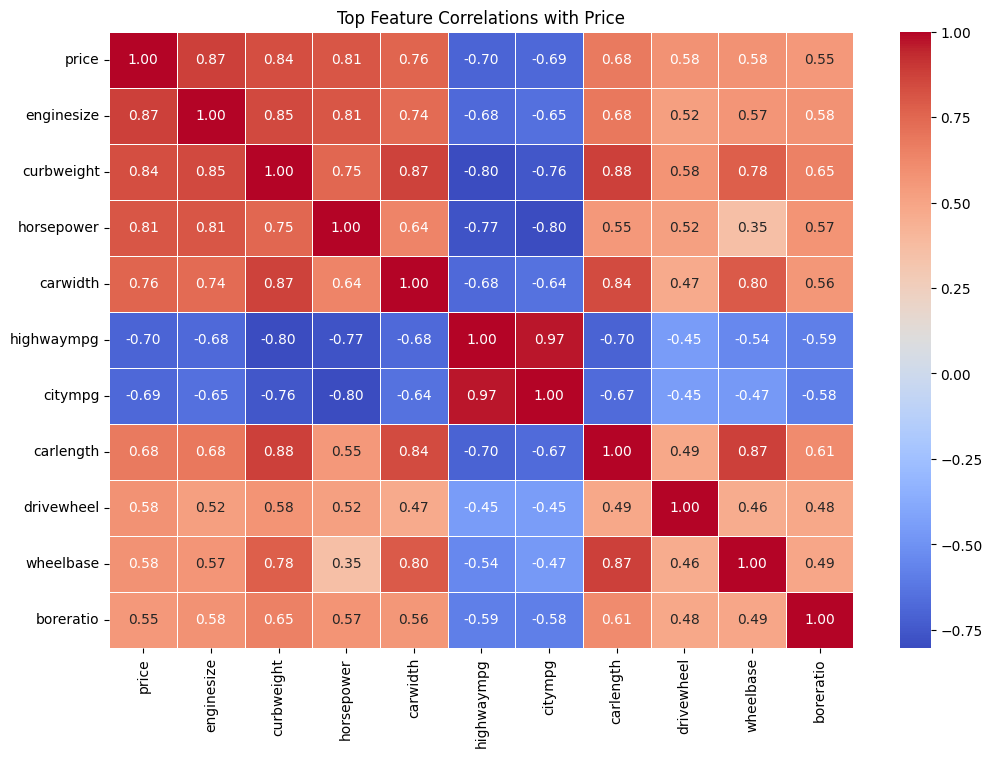

In [26]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
top_corr = df.corr()['price'].abs().sort_values(ascending=False).head(11).index
sns.heatmap(df[top_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Top Feature Correlations with Price')
plt.show()

In [27]:
# ── 7. TRAIN / TEST SPLIT ─────────────────────────────────────
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

Train size: 164
Test size : 41


In [28]:
# ── 8. SCALING (for Linear Regression) ───────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


In [29]:
# ── 9. TRAIN & EVALUATE ALL MODELS ───────────────────────────
models = {
    'Linear Regression' : (LinearRegression(), X_train_sc, X_test_sc),
    'Random Forest'     : (RandomForestRegressor(n_estimators=100, random_state=42), X_train, X_test),
    'Gradient Boosting' : (GradientBoostingRegressor(n_estimators=100, random_state=42), X_train, X_test),
}

results = {}

for name, (model, Xtr, Xte) in models.items():
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)

    results[name] = {'preds': preds, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'model': model}
    print(f"{name:<25} | MAE: {mae:,.0f} | RMSE: {rmse:,.0f} | R²: {r2:.4f}")

Linear Regression         | MAE: 2,091 | RMSE: 3,488 | R²: 0.8459
Random Forest             | MAE: 1,325 | RMSE: 1,873 | R²: 0.9556
Gradient Boosting         | MAE: 1,629 | RMSE: 2,329 | R²: 0.9313


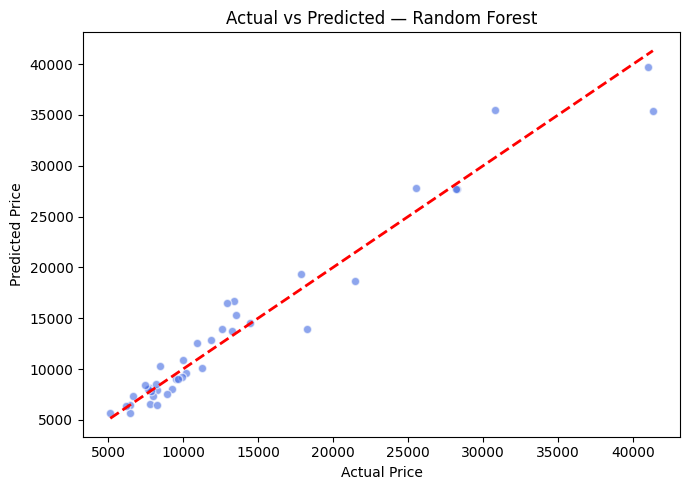


Best Model: Random Forest | R² = 0.9556


In [31]:
# ── 10. ACTUAL vs PREDICTED PLOT (Best Model) ─────────────────
best_name = max(results, key=lambda k: results[k]['R2'])
best_preds = results[best_name]['preds']

plt.figure(figsize=(7, 5))
plt.scatter(y_test, best_preds, alpha=0.6, color='royalblue', edgecolors='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted — {best_name}')
plt.tight_layout()
plt.show()

print(f"\nBest Model: {best_name} | R² = {results[best_name]['R2']:.4f}")